# Home Value Regression

Author: Joaquín Palacios, october 2025

This project aims to build a home value predictor from a dataset scrapped from the Argenprop website that advertise homes and departments on sale and on lease in Argentina. The data is from homes in the Buenos Aires metropilitan area (AMBA) that includes not only the City of Buenos Aires but many municipalities surrounding the city. 

The project includes preparation and exploration of the data, building models with different techiniques and comparing and evaluating them to reach conclusions arround what this data can tell us about the real state market and if we can reach at a valuable predictor for said market. 

## Preparing data

The dataset that we have obtained after a webscrapping of argenprop.com has raw data from the site. We have to clean it and prepare it for exploration and model building.

In [3]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv("argenprop_home_listings.csv")
df.head()

,address,price,rooms,bathrooms,age,covered_surface,terrain_surface
0,Hilarion de la Quintana al 3500,USD 380.000,5,3,A Estrenar,160 m2,300 m2
1,Mariano Moreno al 3100 entre Coronel Francisc...,USD 240.000,5,3,30 años,135 m2,212 m2
2,"Chacabuco al 2000, entre buenos aires y olague...",USD 270.000,4,2,15 años,102 m2,77 m2
3,Jose Ingenieros 2600 entre España y Jonas Salk,USD 147.000,3,1,A Estrenar,81 m2,Not found
4,Hilarión De La Quintana 3500,USD 319.000,4,2,5 años,120 m2,Not found


In [5]:
df['rooms'].unique()

array(['5', '4', '3', '6', '2', '7', '14', '1', '0', '8', '10',
       'Not found', '9', '11', '15', '20'], dtype=object)

In [6]:
df['bathrooms'].unique()

array(['3', '2', '1', '4', '5', '6', 'Not found', '7', '8', '9'],
      dtype=object)

In [7]:
df['age'].unique()

array(['A Estrenar', '30 años', '15 años', '5 años', 'Not found',
       '8 años', '1 año', '25 años', '10 años', '40 años', '70 años',
       '60 años', '45 años', '65 años', '20 años', '50 años', '80 años',
       '6 años', '38 años', '2 años', '4 años', '35 años', '28 años',
       '12 años', '18 años', '3 años', '48 años', '59 años', '47 años',
       '43 años', '55 años', '16 años', '24 años', '39 años', '17 años',
       '37 años', '67 años', '41 años', '49 años', '44 años', '21 años',
       '26 años', '19 años', '23 años', '42 años', '90 años', '9 años',
       '64 años', '14 años', '53 años', '13 años', '7 años', '11 años',
       '51 años', '32 años', '62 años', '27 años', '52 años', '29 años',
       '61 años', '103 años', '46 años', '36 años', '2008 años',
       '31 años', '66 años', '68 años', '22 años', '100 años', '54 años',
       '34 años', '79 años', '1986 años', '85 años', '74 años'],
      dtype=object)

Apart from everything, there's at least a home that has 2008 years old and at least other that has 1986 years. I think the realtor meant to introduce the year of construction of said house as we don't think there are 2000 year old properties laying arround at Buenos Aires. They must have been built by the indegenous people. 

In [9]:
df.loc[df['age']=='A Estrenar','age'] = '0 años'

In [10]:
df['covered_surface'] = df['covered_surface'].str.extract(r'(\d+)', expand=False).astype(float)
df['terrain_surface'] = df['terrain_surface'].str.extract(r'(\d+)', expand=False).astype(float)
df['age'] = df['age'].str.extract(r'(\d+)', expand=False).astype('Int64')
df['rooms'] = df['rooms'].str.extract(r'(\d+)', expand=False).astype('Int64')
df['bathrooms'] = df['bathrooms'].str.extract(r'(\d+)', expand=False).astype('Int64')

In [11]:
df['price'] = df['price'].str.replace(r'\D','',regex=True)
df = df[df['price']!='']
df['price'] = df['price'].astype('Int64')

In [12]:
df = df[df['age']<1900]

Here we make sure those 2000 year old houses don't get pass our final data. Also we made all of our usefull attributes into numerical types for processing. 

In [14]:
df.describe()

,price,rooms,bathrooms,age,covered_surface,terrain_surface
count,1594.0,1579.0,1551.0,1594.0,1542.000000,1431.000000
mean,336274.826851,4.620646,2.63185,25.151192,207.089494,343.197065
std,318977.881375,1.551353,1.304282,20.381893,117.296813,266.816878
min,28500.0,0.0,1.0,0.0,1.000000,1.000000
25%,173225.0,4.0,2.0,6.0,130.000000,158.000000
50%,250000.0,4.0,2.0,23.0,180.000000,290.000000
75%,385000.0,5.0,3.0,40.0,250.000000,506.000000
max,3850000.0,20.0,9.0,103.0,930.000000,995.000000


In [15]:
df['rooms'] = df['rooms'].fillna(int(df['rooms'].mean()))
df['bathrooms'] = df['bathrooms'].fillna(int(df['bathrooms'].mean()))
df['covered_surface'] = df['covered_surface'].fillna(int(df['covered_surface'].mean()))
df['terrain_surface'] = df['terrain_surface'].fillna(int(df['terrain_surface'].mean()))

We filled the na values with the mean of each attribute to have a complete dataset that we can use to explore and make predictions later on.

In [17]:
df.isna().sum()

address            0
price              0
rooms              0
bathrooms          0
age                0
covered_surface    0
terrain_surface    0
dtype: int64

In [18]:
df.describe()

,price,rooms,bathrooms,age,covered_surface,terrain_surface
count,1594.0,1594.0,1594.0,1594.0,1594.000000,1594.000000
mean,336274.826851,4.614806,2.614806,25.151192,207.086575,343.176913
std,318977.881375,1.545195,1.290627,20.381893,115.366481,252.797888
min,28500.0,0.0,1.0,0.0,1.000000,1.000000
25%,173225.0,4.0,2.0,6.0,132.000000,171.000000
50%,250000.0,4.0,2.0,23.0,184.000000,307.500000
75%,385000.0,5.0,3.0,40.0,247.750000,450.000000
max,3850000.0,20.0,9.0,103.0,930.000000,995.000000


In [19]:
df = df.drop('address', axis=1)

We drop the address attribute as it is not usefull to our analysis just yet. We could transform it into a geolocation and then obtain the distances to important services like public transit (AMBA has a robust metro). 

## Exploratory Data Analysis

Here we aim to comprehend the distributions of our data, and obtain insights from it that can be usefull to the feature engineering before we start making models. 

We will start visualizing the correlation matrix through a heatmap. This will turn our attention to meaningfull relations within the dataset. After, we will make a gridplot, that we think is usefull in orther to see the relations expressed before in the corr matrix, as scatterplots and KDE plots for the joint distributions and hisplots for the marginal distributions.

In [22]:
from matplotlib import pyplot as plt
import seaborn as sns

<Axes: >

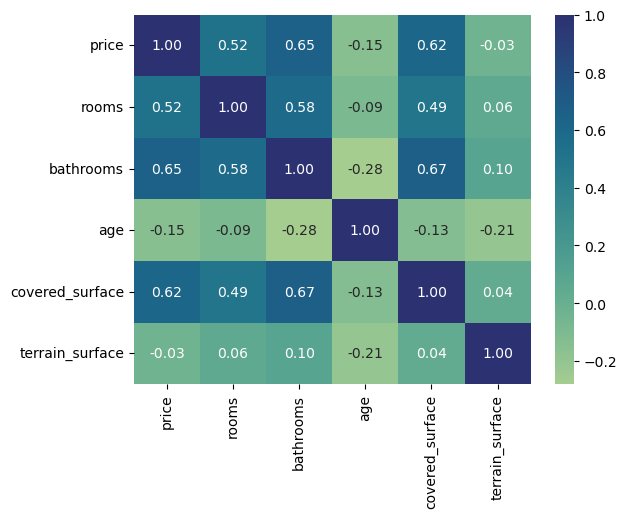

In [23]:
sns.heatmap(df.corr(),annot=True,fmt='.2f',cmap="crest")

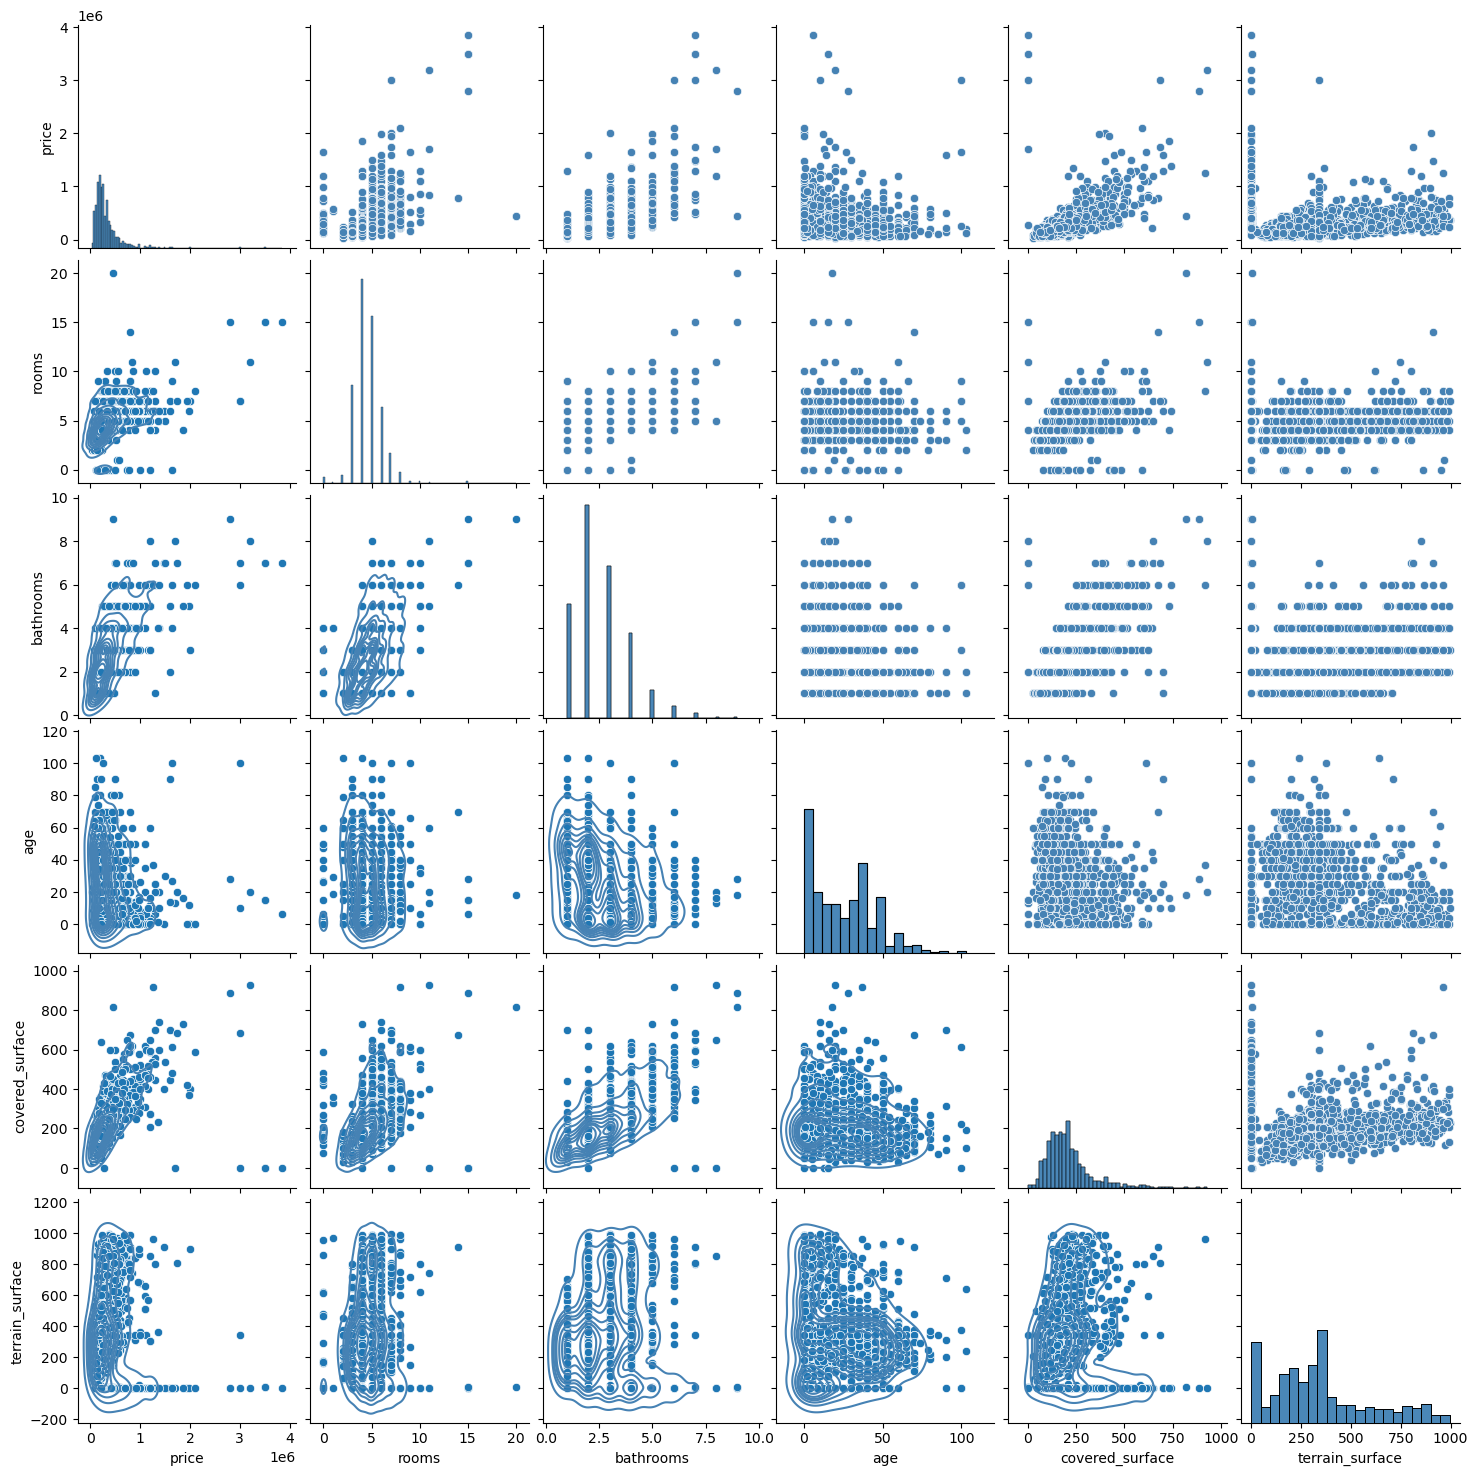

In [24]:
g = sns.pairplot(df)
g.map_diag(sns.histplot, color='steelblue')
g.map_upper(sns.scatterplot, color='steelblue')
g.map_lower(sns.kdeplot, color='steelblue')

As we can see there are coupled relations we the targe variable of our analysis, covered_surface, bathrooms, and rooms. Yet this coupling is not as strong as one may think when watching the real state market and trying to buy or rent a place. 

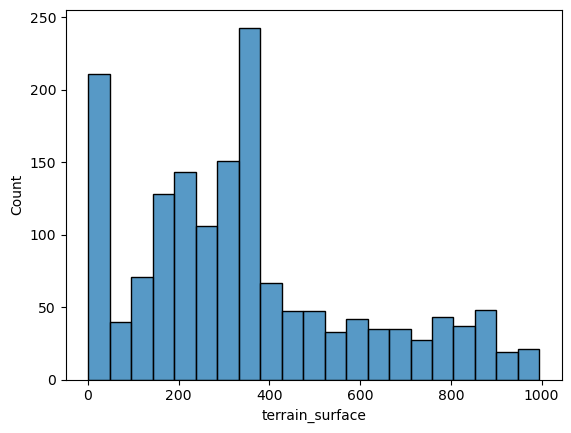

In [26]:
sns.histplot(data=df, x="terrain_surface")
plt.show()

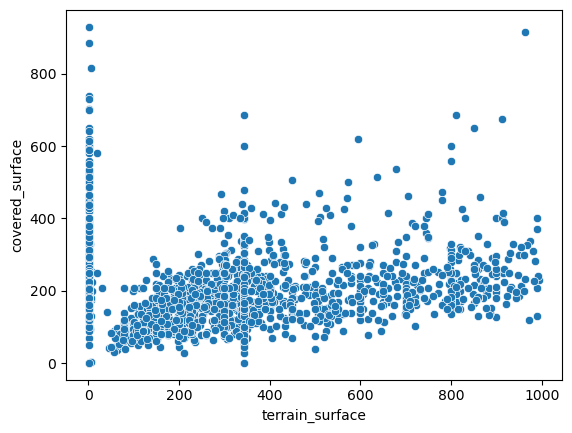

In [27]:
sns.scatterplot(data=df,x='terrain_surface',y='covered_surface')
plt.show()

There's something going on with terrain surface: a lot of it's value are set to 0, but as the terrain has to be bigger than the covered surface. Many realtors may have thought this variable was only as in "the garden area" of the house. 

To make this assumption we can say where the terrain surface is less than the covered surface, it is referring undoubtedly to the garden, so it's a "not covered surface" and the terrain surface must be the sum of both.

## Feature Engineering 

The coupling of certaing attributes leads us to try to tie together certain relationships and watch if we can add more related variables to the models we will build from this data. 

If both rooms and bathrooms are correlated positively with the price we can add an attribute that sums both variables to get the total number of rooms. And if covered surface has a certain correlation also with the price, similar to rooms, we can see if the surface of each room has something to say about the price. Also we tweak the terrain surface and make a new attribute not covered surface

In [30]:
df['total_rooms'] = df['rooms']+df['bathrooms']
df['avg_room_surface'] = df['covered_surface'] / df['rooms']
df['terrain_surface'] = np.where(df['terrain_surface']<df['covered_surface'],
                                 df['terrain_surface']+df['covered_surface'],
                                 df['terrain_surface'])
df['not_covered_surface'] = df['terrain_surface']-df['covered_surface']
df.loc[df['avg_room_surface']==float('inf'),'avg_room_surface'] = df['avg_room_surface'].quantile(0.98)
df.loc[df['not_covered_surface']<0,'not_covered_surface'] = 0

<Axes: >

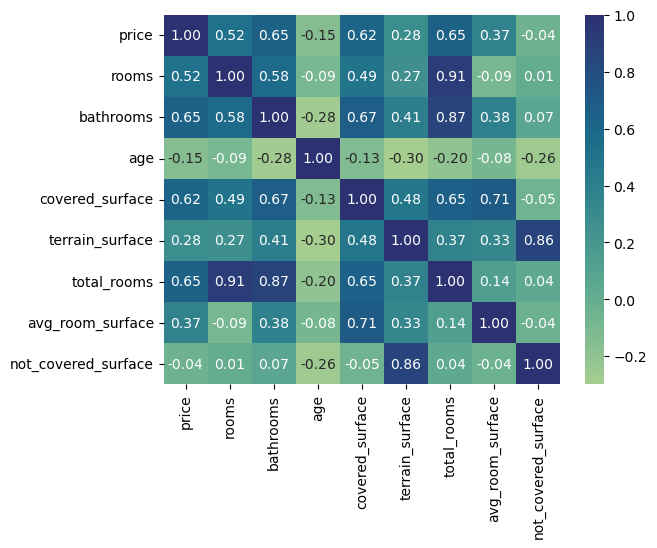

In [31]:
sns.heatmap(df.corr(),annot=True,fmt='.2f',cmap="crest")

The new corr matrix add some relationships that we hope can be usefull, as it corrects the terrain surface correlation with the price, although the not covered surface doesn't add to much information there. The total rooms correlation must be a redundancy from the bathrooms correlation. The avg room surface also correlates somewhat although not as enough as we initially thought. 

We'll see how well can a regression model perform with this set of attributes

## Model Building

We'll start making a linear regression model from the sklearn library. In other notebook, we implemented a linear regression model that trains itself with the gradient descent method, but this time we'll rely on the given library. For preprocessing we'll make a pipeline with the scaler that turns all attributes into un-dimensional values scaled by it's own distribution. This is important beacuse it gives every attribute the same weight no matter it's magnitude. 

The task of regression will be analyzed trough the most important metrics we have at our disposal: the root mean squared error that tells us how in average is our predictor wrong about the values it predicts and the coefficient of determination that tells us how well the model explains the variability in our target variable, and the adjusted extension that takes out of consideration the extended dimensions (as independent variables).

In [34]:
from sklearn.metrics import root_mean_squared_error, r2_score

def evaluate_model(model, X_test, y_test):
    y_predict = model.predict(X_test)
    rmse = root_mean_squared_error(y_test, y_predict)
    rsq = r2_score(y_test, y_predict)
    rbsq = 1-(1-rsq)*(y_predict.shape[0]-1)/(y_predict.shape[0]-X.shape[1]-1)
    return rmse, rsq, rbsq

In [35]:
X = df.drop(columns=['price'])
y = pd.DataFrame(df['price'])

In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [37]:
scaler = StandardScaler()
X = scaler.fit_transform(X)
y = scaler.fit_transform(y)

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.33, random_state=43)

In [39]:
print(f"Shapes: {X_train.shape}, {X_test.shape}, {y_train.shape}, {y_test.shape}")

Shapes: (1067, 8), (527, 8), (1067, 1), (527, 1)


In [40]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [41]:
rmse, rsq, rbsq = evaluate_model(lr, X_test, y_test)
print(f"RMSE: {rmse:.4f}, R² value: {rsq:.4f}, Adjusted R²: {rbsq:.4f}")

RMSE: 0.6547, R² value: 0.5882, Adjusted R²: 0.5819


The root mean sq error is realatively high and our R² value is pretty low. There is not much that this model can say us about a given house that it doesn't know from it's training data. Certainly this model is as reliable as a realtor's gut at predicting a house value. 

Other alternative we can evaluate is to drop certain attributes that we don't see as correlated to the target variable to see if this makes an improvement in the metrics we setted for our model.

In [43]:
X = df.drop(columns=['price','age','not_covered_surface','terrain_surface'])

In [44]:
X = scaler.fit_transform(X)

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.33, random_state=43)

In [46]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [47]:
rmse, rsq, rbsq = evaluate_model(lr, X_test, y_test)
print(f"RMSE: {rmse:.4f}, R² value: {rsq:.4f}, Adjusted R²: {rbsq:.4f}")

RMSE: 0.6558, R² value: 0.5868, Adjusted R²: 0.5828


As we can see, although the R² value is slightly lower, the adjusted version is at the same rate higher. Nonetheless, those values are still way to low to make our linear regression model as a predictor for the AMBA real state market. We need to evaluate other options and those may be as a random forest regressor. 

In [49]:
y_train.shape

(1067, 1)

In [50]:
X = df.drop(columns=['price'])
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.33, random_state=43)

In [51]:
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor()
rfr.fit(X_train,y_train.ravel())

RandomForestRegressor()

In [52]:
rmse, rsq, rbsq = evaluate_model(rfr, X_test, y_test)
print(f"RMSE: {rmse:.4f}, R² value: {rsq:.4f}, Adjusted R²: {rbsq:.4f}")

RMSE: 0.5182, R² value: 0.7421, Adjusted R²: 0.7381


In [53]:
from sklearn.svm import SVR
svr = SVR(kernel='rbf', C=1.0, epsilon=0.1, gamma='scale')
svr.fit(X_train,y_train.ravel())

SVR()

In [54]:
rmse, rsq, rbsq = evaluate_model(svr, X_test, y_test)
print(f"RMSE: {rmse:.4f}, R² value: {rsq:.4f}, Adjusted R²: {rbsq:.4f}")

RMSE: 0.6564, R² value: 0.5861, Adjusted R²: 0.5797


As we can see by the models we builded, it is tough to find good predictions within our data. We knew it was not going to be easy, though. 

As we tried to change the parameters in the training of the linear regression, but took no better performance out of it, and the random forest regressor shows more promise, we are going to fine tune it to see what happens, and if we can achieve our goal to have a good predictor for our target variable.

In [56]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {'n_estimators':[10,20,50,100],'max_depth':[None,10,20,30,40],'max_features':[1,2,4,6,8]},
]

rfr = RandomForestRegressor()

grid_search = GridSearchCV(rfr, param_grid, cv = 5, 
                           scoring = 'neg_root_mean_squared_error', 
                           return_train_score = True)


In [57]:
grid_search.fit(X_train, y_train.ravel())

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid=[{'max_depth': [None, 10, 20, 30, 40],
                          'max_features': [1, 2, 4, 6, 8],
                          'n_estimators': [10, 20, 50, 100]}],
             return_train_score=True, scoring='neg_root_mean_squared_error')

In [58]:
rmse, rsq, rbsq = evaluate_model(grid_search.best_estimator_, X_test, y_test)
print(f"RMSE: {rmse:.4f}, R² value: {rsq:.4f}, Adjusted R²: {rbsq:.4f}")

RMSE: 0.5364, R² value: 0.7236, Adjusted R²: 0.7193


In [59]:
grid_search.best_params_

{'max_depth': 10, 'max_features': 1, 'n_estimators': 10}

In [60]:
cvres = grid_search.cv_results_
for mean_score, params in zip(cvres['mean_test_score'],cvres['params']):
    print(f"RMSE: {-mean_score:.4f} for {params}")

RMSE: 0.5971 for {'max_depth': None, 'max_features': 1, 'n_estimators': 10}
RMSE: 0.5927 for {'max_depth': None, 'max_features': 1, 'n_estimators': 20}
RMSE: 0.5911 for {'max_depth': None, 'max_features': 1, 'n_estimators': 50}
RMSE: 0.5917 for {'max_depth': None, 'max_features': 1, 'n_estimators': 100}
RMSE: 0.5971 for {'max_depth': None, 'max_features': 2, 'n_estimators': 10}
RMSE: 0.5930 for {'max_depth': None, 'max_features': 2, 'n_estimators': 20}
RMSE: 0.5987 for {'max_depth': None, 'max_features': 2, 'n_estimators': 50}
RMSE: 0.5835 for {'max_depth': None, 'max_features': 2, 'n_estimators': 100}
RMSE: 0.6015 for {'max_depth': None, 'max_features': 4, 'n_estimators': 10}
RMSE: 0.6176 for {'max_depth': None, 'max_features': 4, 'n_estimators': 20}
RMSE: 0.5929 for {'max_depth': None, 'max_features': 4, 'n_estimators': 50}
RMSE: 0.6038 for {'max_depth': None, 'max_features': 4, 'n_estimators': 100}
RMSE: 0.6389 for {'max_depth': None, 'max_features': 6, 'n_estimators': 10}
RMSE: 0.6

At last, we tweaked many hyperparameters for the random forest regressor and obtained close model to the one we originally tried, without a great improvement. Although it is not improved, performs better than the other two alternatives we worked with, a linear model and a Support Vector Regressor.

## Conclusion

Finally, throughout this projet we worked with data manipulation to clean and feature engineer the data, after performing an exploratory data analysis with many insights. After we tried to build a regressor model that could predict satisfactorily our target variable, we obtained a model that can explain the 70% of the target variable variation, and which predictions are in average half of the target variable standard deviation skewed. In other words almost 95% of the model predictions will be within the range of 2 standard deviations.

Is this a good model? For the context that we setted and the data that we obtained is as good as it gets. For a more serious and dedicated aproach we may use the address attribute we droped at the start, and search for historical land value data for each property, as an alternative to obtain more independent variables that can explain the price of a house. 